# Bingah Mahcha Hanifa — Submission Akhir DLTM
## Multivariate Multi-Horizon Time Series Forecasting (Bitcoin)


In [1]:
# Cell 1: Import library dan download dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

file_path = 'Bitcoin3.csv'
df = pd.read_csv(file_path)
print(df.head())
print(df.info())

                      Date    Close    Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00   74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48   44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95   80546.171672  49.210685 -47.308061   
3  2017-09-21 12:00:00.000  3858.08   90331.531390  49.186948 -46.863233   
4  2017-09-21 13:00:00.000  3856.67  103405.818040  49.182064 -46.425379   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  
3  87.720856  2.447245  
4  87.578086  2.424654  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null 

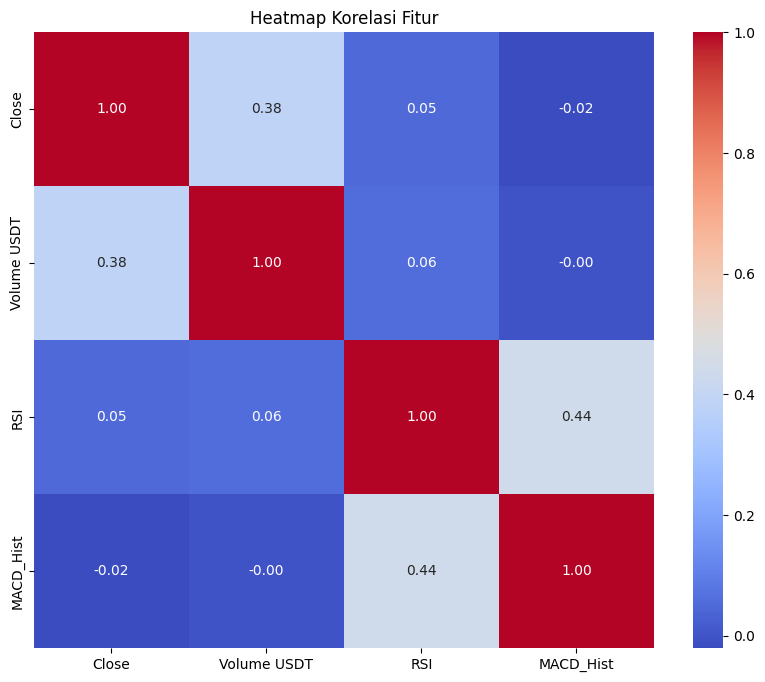

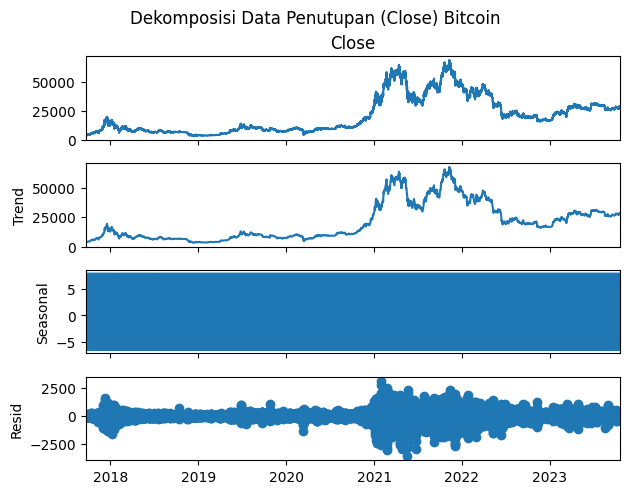

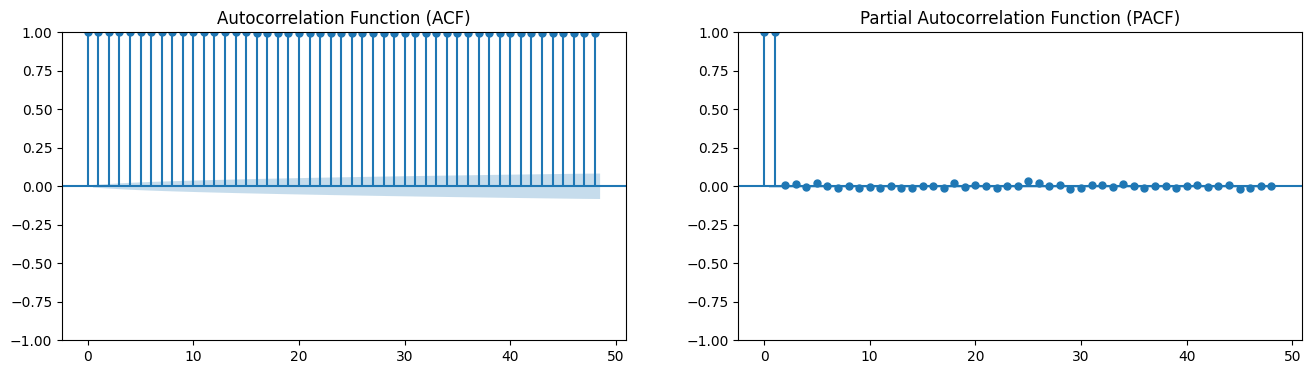

In [2]:
# Cell 2: EDA, Korelasi, Dekomposisi, ACF & PACF
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df.set_index('Date', inplace=True)

# Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Close', 'Volume USDT', 'RSI', 'MACD_Hist']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()

# Analisis Dekomposisi pada data Target ('Close')
decompose_result = seasonal_decompose(df['Close'].dropna(), model='additive', period=24)
decompose_result.plot()
plt.suptitle('Dekomposisi Data Penutupan (Close) Bitcoin', y=1.02)
plt.show()

# Uji ACF dan PACF
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Close'].dropna(), lags=48, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(df['Close'].dropna(), lags=48, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')
plt.show()
# window_size = 24 dipilih berdasarkan seasonality harian (24 jam) dari hasil PACF.

In [3]:
# Cell 3: Feature Engineering & Min-Max Scaler (TANPA DATA LEAKAGE)
df['rolling_mean_close_24'] = df['Close'].rolling(window=24).mean()
df.dropna(inplace=True)

features   = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'rolling_mean_close_24']
data       = df[features].values
target_idx = features.index('Close')

n          = len(data)
train_data = data[0:int(n*0.7)]
val_data   = data[int(n*0.7):int(n*0.9)]
test_data  = data[int(n*0.9):]

# fit HANYA pada train, tidak ada data leakage
train_min = train_data.min(axis=0)
train_max = train_data.max(axis=0)

train_data_scaled = (train_data - train_min) / (train_max - train_min)
val_data_scaled   = (val_data   - train_min) / (train_max - train_min)
test_data_scaled  = (test_data  - train_min) / (train_max - train_min)

print(f"Data latih : {train_data_scaled.shape}")
print(f"Data val   : {val_data_scaled.shape}")
print(f"Data test  : {test_data_scaled.shape}")

Data latih : (37188, 5)
Data val   : (10626, 5)
Data test  : (5313, 5)


In [4]:
# Cell 4: tf.data.Dataset Pipeline
window_size = 24
horizon     = 24

def create_multi_horizon_dataset(data, window_size, horizon, batch_size=32):
    X, Y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i + window_size)])
        Y.append(data[(i + window_size):(i + window_size + horizon), target_idx])
    X = np.array(X)
    Y = np.array(Y)
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    return dataset.shuffle(buffer_size=1000, seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_multi_horizon_dataset(train_data_scaled, window_size, horizon)
val_ds   = create_multi_horizon_dataset(val_data_scaled,   window_size, horizon)
test_ds  = create_multi_horizon_dataset(test_data_scaled,  window_size, horizon, batch_size=64)

print("Pipeline tf.data.Dataset berhasil dibuat!")

Pipeline tf.data.Dataset berhasil dibuat!


In [5]:
# Cell 5: Custom Layers

# Custom Layer 1: Dense dari nol
@tf.keras.utils.register_keras_serializable()
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

    def get_config(self):
        config = super(CustomDense, self).get_config()
        config.update({"units": self.units})
        return config


# Custom Layer 2: Activation Function Leaky ReLU dari nol
@tf.keras.utils.register_keras_serializable()
class CustomLeakyReLU(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super(CustomLeakyReLU, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)

    def get_config(self):
        config = super(CustomLeakyReLU, self).get_config()
        config.update({"alpha": self.alpha})
        return config


# Custom Layer 3: Multi-Head Attention dari nol
@tf.keras.utils.register_keras_serializable()
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim   = key_dim
        self.wq    = tf.keras.layers.Dense(num_heads * key_dim)
        self.wk    = tf.keras.layers.Dense(num_heads * key_dim)
        self.wv    = tf.keras.layers.Dense(num_heads * key_dim)
        self.dense = tf.keras.layers.Dense(num_heads * key_dim)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v):
        batch_size = tf.shape(q)[0]
        q, k, v = self.wq(q), self.wk(k), self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        attention_weights = tf.nn.softmax(matmul_qk / tf.math.sqrt(dk), axis=-1)
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat = tf.reshape(output, (batch_size, -1, self.num_heads * self.key_dim))
        return self.dense(concat)

    def get_config(self):
        config = super(CustomMultiHeadAttention, self).get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

print("Tiga Custom Layer berhasil didefinisikan!")

Tiga Custom Layer berhasil didefinisikan!


In [6]:
# Cell 6: Membangun Model Baseline LSTM & Seq2Seq LSTM

# Baseline LSTM — Functional API
inputs = tf.keras.Input(shape=(window_size, len(features)))
x = tf.keras.layers.LSTM(128, return_sequences=True)(inputs)
x = CustomMultiHeadAttention(num_heads=4, key_dim=32)(x, x, x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = CustomDense(128)(x)
x = CustomLeakyReLU()(x)
x = tf.keras.layers.Dropout(0.1)(x)
outputs = CustomDense(horizon)(x)
baseline_model = tf.keras.Model(inputs, outputs, name="Baseline_LSTM")
baseline_model.summary()


# Seq2Seq LSTM — Model Subclassing
@tf.keras.utils.register_keras_serializable()
class Encoder(tf.keras.layers.Layer):
    def __init__(self, units=128, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        self.units = units
        self.lstm  = tf.keras.layers.LSTM(units, return_state=True, return_sequences=True)
        self.mha   = CustomMultiHeadAttention(num_heads=4, key_dim=32)

    def call(self, inputs):
        x, state_h, state_c = self.lstm(inputs)
        x = self.mha(x, x, x)
        return x, state_h, state_c

    def get_config(self):
        config = super(Encoder, self).get_config()
        config.update({"units": self.units})
        return config


@tf.keras.utils.register_keras_serializable()
class Decoder(tf.keras.layers.Layer):
    def __init__(self, units=128, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        self.units     = units
        self.lstm      = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.mha       = CustomMultiHeadAttention(num_heads=4, key_dim=32)
        self.dense1    = CustomDense(64)
        self.act       = CustomLeakyReLU()
        self.dropout   = tf.keras.layers.Dropout(0.1)
        self.dense_out = CustomDense(1)

    def call(self, x, initial_state, enc_output, training=False):
        x, state_h, state_c = self.lstm(x, initial_state=initial_state)
        x = self.mha(x, enc_output, enc_output)
        x = self.act(self.dense1(x))
        x = self.dropout(x, training=training)
        return self.dense_out(x), state_h, state_c

    def get_config(self):
        config = super(Decoder, self).get_config()
        config.update({"units": self.units})
        return config


@tf.keras.utils.register_keras_serializable()
class Seq2SeqModel(tf.keras.Model):
    def __init__(self, horizon, units=128, **kwargs):
        super(Seq2SeqModel, self).__init__(**kwargs)
        self.horizon = horizon
        self.units   = units
        self.encoder = Encoder(units=units)
        self.decoder = Decoder(units=units)

    def call(self, inputs, target_seq=None, training=False, tf_ratio=1.0):
        """
        tf_ratio: float 0.0-1.0.
          1.0 = full teacher forcing (pakai ground truth saat training).
          0.0 = full autoregressive (pakai prediksi model).
          Nilai tengah = scheduled teacher forcing (probabilistik).
        """
        enc_output, state_h, state_c = self.encoder(inputs)
        states    = [state_h, state_c]
        dec_input = tf.expand_dims(inputs[:, -1, target_idx:target_idx+1], 1)
        outputs   = []

        for t in range(self.horizon):
            predictions, state_h, state_c = self.decoder(
                dec_input, states, enc_output, training=training)
            states = [state_h, state_c]
            outputs.append(predictions[:, 0, 0])

            if training and target_seq is not None:
                use_teacher  = tf.random.uniform(shape=()) < tf_ratio
                ground_truth = tf.expand_dims(target_seq[:, t:t+1], 1)
                dec_input    = tf.cond(use_teacher,
                                       lambda: ground_truth,
                                       lambda: predictions)
            else:
                dec_input = predictions

        return tf.transpose(tf.stack(outputs), [1, 0])

    def get_config(self):
        config = super(Seq2SeqModel, self).get_config()
        config.update({"horizon": self.horizon, "units": self.units})
        return config


seq2seq_model = Seq2SeqModel(horizon=24, units=128)
print("Baseline LSTM dan Seq2Seq LSTM berhasil dibangun!")

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 128)   │     68,608 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 128) │     66,048 │ lstm[0][0],       │
│ (CustomMultiHeadAt… │                   │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ custom_multi_hea… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense        │ (None, 128)       │     16,512 │ global_average_p… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_leaky_re_lu  │ (None, 128)       │          0 │ custom_dense[0][… │
│ (CustomLeakyReLU)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ custom_leaky_re_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 24)        │      3,096 │ dropout[0][0]     │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 154,264 (602.59 KB)

 Trainable params: 154,264 (602.59 KB)

 Non-trainable params: 0 (0.00 B)

Baseline LSTM dan Seq2Seq LSTM berhasil dibangun!


In [7]:
# Cell 7: Custom Loss & Custom Callbacks

# Terdapat DUA Custom Loss:
#   1. CustomMAELoss   — MAE murni dari nol (memenuhi syarat Skilled K3)
#   2. WeightedMAELoss — MAE berbobot bertahap (memenuhi syarat Advanced K3)

# CUSTOM LOSS 1: MAE Loss dari nol (Skilled K3)
class CustomMAELoss(tf.keras.losses.Loss):
    """
    Mean Absolute Error (MAE) dibangun dari nol — tanpa menggunakan
    tf.keras.losses.MeanAbsoluteError bawaan.
    MAE = mean( |y_true - y_pred| )
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        abs_error = tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32))
        return tf.reduce_mean(abs_error)


# CUSTOM LOSS 2: Weighted MAE Loss (Advanced K3)
# Weight bertahap: step 1=1.0, step 2=1.2, step 3=1.4, ...
class WeightedMAELoss(tf.keras.losses.Loss):
    """
    MAE Loss dengan bobot bertahap per step horizon.
    Semakin jauh step, semakin besar penaltinya.
    """
    def __init__(self, horizon, weight_increment=0.2, **kwargs):
        super().__init__(**kwargs)
        self.horizon          = horizon
        self.weight_increment = weight_increment
        self.weights = tf.constant(
            [1.0 + (weight_increment * i) for i in range(horizon)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        abs_error      = tf.abs(y_true - y_pred)
        weighted_error = abs_error * self.weights
        return tf.reduce_mean(weighted_error)


custom_loss_fn = WeightedMAELoss(horizon=24, weight_increment=0.2)
eval_mae_fn    = CustomMAELoss()

print("Custom Loss berhasil didefinisikan:")
print(f"  CustomMAELoss   (Skilled)  : {eval_mae_fn.name}")
print(f"  WeightedMAELoss (Advanced) : {custom_loss_fn.name}")
print(f"  Bobot 5 step pertama: {custom_loss_fn.weights.numpy().tolist()[:5]}")


# CUSTOM CALLBACK: Early Stopping + Reduce LR on Plateau + Scheduled TF
class CustomCallbacks:
    """
    Custom Callback dengan tiga mekanisme:
    1. Early Stopping       — hentikan jika val_loss stagnan selama patience_es epoch.
    2. Reduce LR on Plateau — kurangi LR secara bertahap jika val_loss stagnan
                              selama patience_lr epoch berturut-turut.
    3. Scheduled Teacher Forcing — tf_ratio turun bertahap tiap tf_schedule_steps epoch,
                              mendorong model belajar mandiri secara progresif.
    """
    def __init__(self, patience_es=20, patience_lr=7, factor=0.5,
                 tf_schedule_steps=5, tf_decrement=0.05, min_tf_ratio=0.0):
        self.best_loss         = float('inf')
        self.wait_es           = 0
        self.wait_lr           = 0
        self.patience_es       = patience_es
        self.patience_lr       = patience_lr
        self.factor            = factor
        self.stop_training     = False
        self.tf_ratio          = 1.0
        self.tf_schedule_steps = tf_schedule_steps
        self.tf_decrement      = tf_decrement
        self.min_tf_ratio      = min_tf_ratio

    def on_epoch_end(self, epoch, val_loss, optimizer):
        # Scheduled Teacher Forcing
        if (epoch + 1) % self.tf_schedule_steps == 0:
            self.tf_ratio = max(self.min_tf_ratio, self.tf_ratio - self.tf_decrement)
            print(f"  [TF Schedule] tf_ratio -> {self.tf_ratio:.2f}")

        # Cek val_loss
        if val_loss < self.best_loss - 1e-5:
            self.best_loss = val_loss
            self.wait_es   = 0
            self.wait_lr   = 0
        else:
            self.wait_es += 1
            self.wait_lr += 1

        # Reduce LR on Plateau
        if self.wait_lr >= self.patience_lr:
            old_lr = float(optimizer.learning_rate)
            new_lr = max(old_lr * self.factor, 1e-7)
            optimizer.learning_rate.assign(new_lr)
            print(f"  [Reduce LR]   {old_lr:.2e} -> {new_lr:.2e}")
            self.wait_lr = 0

        # Early Stopping
        if self.wait_es >= self.patience_es:
            print(f"  [Early Stop]  Epoch {epoch+1}. Best: {self.best_loss:.5f}")
            self.stop_training = True


custom_callbacks = CustomCallbacks(
    patience_es=20, patience_lr=7, factor=0.5,
    tf_schedule_steps=5, tf_decrement=0.05, min_tf_ratio=0.0
)
print("Custom Callbacks berhasil dikonfigurasi!")

Custom Loss berhasil didefinisikan:
  CustomMAELoss   (Skilled)  : custom_mae_loss
  WeightedMAELoss (Advanced) : weighted_mae_loss
  Bobot 5 step pertama: [1.0, 1.2000000476837158, 1.399999976158142, 1.600000023841858, 1.7999999523162842]
Custom Callbacks berhasil dikonfigurasi!


In [8]:
# Cell 8: Custom Training Loop dengan Teacher Forcing & Gradient Clipping
import time

epochs    = 150
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=0.5)

# Training Baseline LSTM (model.fit())
print("=" * 65)
print("Training Baseline LSTM (model.fit())")
print("=" * 65)
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mae')
baseline_model.fit(train_ds, validation_data=val_ds, epochs=20, verbose=1)

# Custom Train / Val / Eval functions
@tf.function
def train_step(x, y, tf_ratio):
    with tf.GradientTape() as tape:
        predictions = seq2seq_model(x, target_seq=y, training=True, tf_ratio=tf_ratio)
        loss = custom_loss_fn(y, predictions)
    gradients = tape.gradient(loss, seq2seq_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, seq2seq_model.trainable_variables))
    return loss

@tf.function
def val_step(x, y):
    predictions = seq2seq_model(x, training=False)
    return custom_loss_fn(y, predictions)

@tf.function
def eval_mae_step(x, y):
    predictions = seq2seq_model(x, training=False)
    return eval_mae_fn(y, predictions)

# Custom Training Loop Seq2Seq (tf.GradientTape)
print("\n" + "=" * 65)
print("Custom Training Loop Seq2Seq (tf.GradientTape)")
print("=" * 65)

for epoch in range(epochs):
    start_time = time.time()
    train_loss = tf.keras.metrics.Mean()
    val_loss_m = tf.keras.metrics.Mean()
    eval_mae_m = tf.keras.metrics.Mean()

    current_tf = tf.constant(custom_callbacks.tf_ratio, dtype=tf.float32)

    for x_batch, y_batch in train_ds:
        loss = train_step(x_batch, y_batch, current_tf)
        train_loss(loss)

    for x_batch, y_batch in val_ds:
        val_loss_m(val_step(x_batch, y_batch))
        eval_mae_m(eval_mae_step(x_batch, y_batch))

    waktu      = time.time() - start_time
    val_result = val_loss_m.result().numpy()
    mae_result = eval_mae_m.result().numpy()

    print(f"Epoch {epoch+1:3d}/{epochs} ({waktu:.0f}s) | "
          f"Loss: {train_loss.result():.5f} | "
          f"Val Loss: {val_result:.5f} | "
          f"Val MAE: {mae_result:.5f} | "
          f"TF: {custom_callbacks.tf_ratio:.2f}")

    custom_callbacks.on_epoch_end(epoch, val_result, optimizer)
    if custom_callbacks.stop_training:
        print(f"Training dihentikan di epoch {epoch+1}.")
        break

print("Training selesai!")

Training Baseline LSTM (model.fit())
Epoch 1/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.0140 - val_loss: 0.0125
Epoch 2/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0121 - val_loss: 0.0166
Epoch 3/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0110 - val_loss: 0.0117
Epoch 4/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0105 - val_loss: 0.0182
Epoch 5/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 6/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0097 - val_loss: 0.0192
Epoch 7/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0095 - val_loss: 0.0129
Epoch 8/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0091 - val_loss: 0.0119
Epoch 9/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0094 - val_loss: 0.0238
Epoch 10/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0090 - val_loss: 0.0164
Epoch 11/20
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.008

--> MAE Baseline LSTM : 0.00678
--> MAE Seq2Seq LSTM  : 0.00699
Target Advanced: Performa Seq2Seq di bawah 0.015 MAE TERPENUHI!


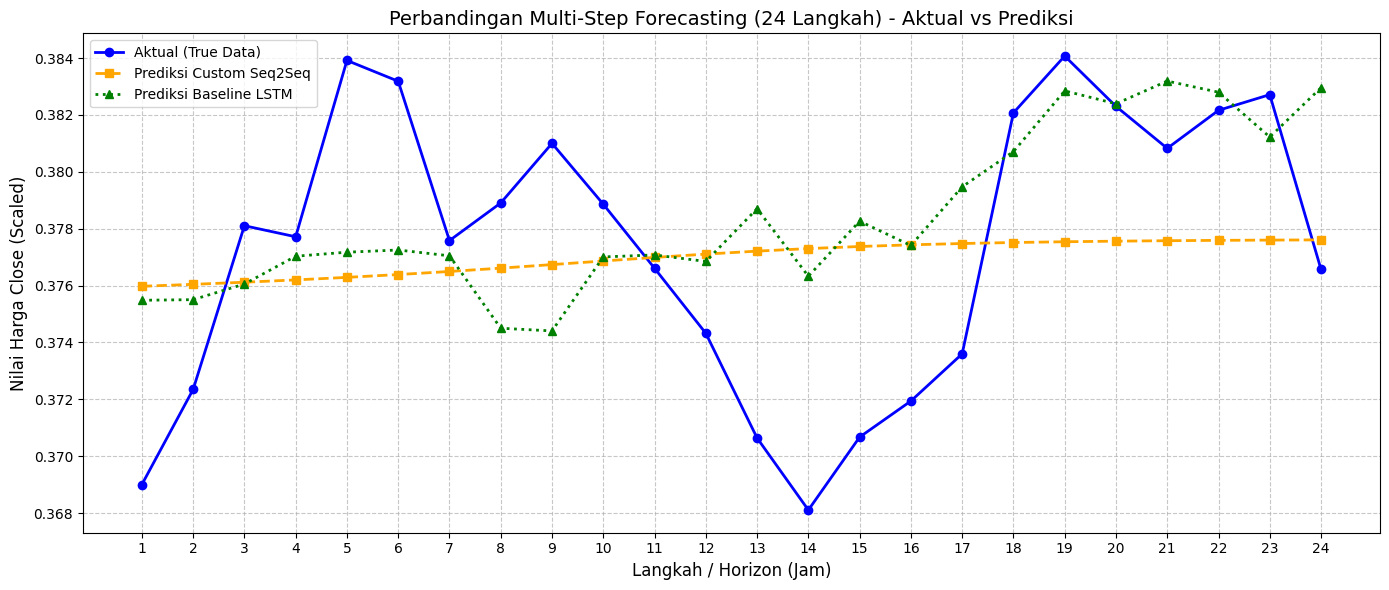


--- Tabel Perbandingan Aktual vs Prediksi ---


,Langkah,Aktual,Prediksi Baseline,Prediksi Seq2Seq,Selisih (Aktual vs Seq2Seq)
0,1,0.369005,0.375484,0.375975,0.006970
1,2,0.372349,0.375505,0.376044,0.003695
2,3,0.378104,0.376055,0.376118,0.001986
3,4,0.377716,0.377032,0.376199,0.001517
4,5,0.383914,0.377174,0.376289,0.007625
5,6,0.383183,0.377251,0.376388,0.006796
6,7,0.377583,0.377047,0.376496,0.001087
7,8,0.378905,0.374501,0.376613,0.002291
8,9,0.380999,0.374406,0.376738,0.004261
9,10,0.378860,0.377007,0.376865,0.001996



model_baseline_LSTM.keras dan model_seq2seq_LSTM.keras berhasil disimpan!


In [9]:
# Cell 9: Inference, Evaluasi, Visualisasi & Simpan Model
import pandas as pd
import matplotlib.pyplot as plt

# Inference pada data test
y_true_list, y_pred_seq2seq_list, y_pred_baseline_list = [], [], []

for x_batch, y_batch in test_ds:
    pred_seq2seq  = seq2seq_model(x_batch, training=False)   # Autoregressive
    pred_baseline = baseline_model(x_batch, training=False)
    y_true_list.append(y_batch.numpy())
    y_pred_seq2seq_list.append(pred_seq2seq.numpy())
    y_pred_baseline_list.append(pred_baseline.numpy())

y_true_all          = np.vstack(y_true_list)
y_pred_seq2seq_all  = np.vstack(y_pred_seq2seq_list)
y_pred_baseline_all = np.vstack(y_pred_baseline_list)

# Evaluasi MAE (sebelum inverse scale)
mae_baseline = np.mean(np.abs(y_true_all - y_pred_baseline_all))
mae_seq2seq  = np.mean(np.abs(y_true_all - y_pred_seq2seq_all))

print(f"--> MAE Baseline LSTM : {mae_baseline:.5f}")
print(f"--> MAE Seq2Seq LSTM  : {mae_seq2seq:.5f}")

if mae_seq2seq < 0.015:
    print("Target Advanced: Performa Seq2Seq di bawah 0.015 MAE TERPENUHI!")
else:
    print(f"MAE saat ini {mae_seq2seq:.5f}. Tambah epoch atau cek arsitektur.")

# Visualisasi Line Chart
sample_idx = 0
aktual_sample        = y_true_all[sample_idx]
pred_seq2seq_sample  = y_pred_seq2seq_all[sample_idx]
pred_baseline_sample = y_pred_baseline_all[sample_idx]
langkah = range(1, horizon + 1)

plt.figure(figsize=(14, 6))
plt.plot(langkah, aktual_sample,         marker='o', label='Aktual (True Data)',       color='blue',   linewidth=2)
plt.plot(langkah, pred_seq2seq_sample,   marker='s', label='Prediksi Custom Seq2Seq',  color='orange', linestyle='--', linewidth=2)
plt.plot(langkah, pred_baseline_sample,  marker='^', label='Prediksi Baseline LSTM',   color='green',  linestyle=':',  linewidth=2)
plt.title('Perbandingan Multi-Step Forecasting (24 Langkah) - Aktual vs Prediksi', fontsize=14)
plt.xlabel('Langkah / Horizon (Jam)', fontsize=12)
plt.ylabel('Nilai Harga Close (Scaled)', fontsize=12)
plt.xticks(langkah)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Tabel Perbandingan
df_comparison = pd.DataFrame({
    'Langkah'          : list(langkah),
    'Aktual'           : aktual_sample,
    'Prediksi Baseline': pred_baseline_sample,
    'Prediksi Seq2Seq' : pred_seq2seq_sample,
})
df_comparison['Selisih (Aktual vs Seq2Seq)'] = np.abs(
    df_comparison['Aktual'] - df_comparison['Prediksi Seq2Seq'])
print("\n--- Tabel Perbandingan Aktual vs Prediksi ---")
display(df_comparison)

baseline_model.save('model_baseline_LSTM.keras')
seq2seq_model.save('model_seq2seq_LSTM.keras')
print("\nmodel_baseline_LSTM.keras dan model_seq2seq_LSTM.keras berhasil disimpan!")

In [10]:
# Cell 10: Generate requirements.txt
get_ipython().system('pip freeze > requirements.txt')
print("File requirements.txt berhasil dibuat!")

File requirements.txt berhasil dibuat!
